# Backpropagation from Scratch with Bayesian Optimization

<div style="background:linear-gradient(135deg,#060b16 0%,#0e1a3a 45%,#130d2b 100%);border:1px solid #1e2d5e;border-radius:16px;padding:28px 32px;font-family:'Courier New',monospace;max-width:920px;margin:20px 0 16px 0;">
  <div style="font-size:10px;letter-spacing:0.2em;text-transform:uppercase;color:#818cf8;margin-bottom:12px;">// NOTEBOOK OVERVIEW</div>
  <div style="font-size:22px;font-weight:800;color:#fff;margin-bottom:14px;">Backpropagation + Bayesian Weight Optimization</div>
  <p style="color:#94a3b8;font-size:13.5px;line-height:1.75;margin-bottom:22px;">
    Full backpropagation implemented in NumPy from first principles, including He/Xavier initialization, mini-batch SGD, L2 regularization, and analytical gradient verification via numerical checking.
    Bayesian Optimization (Gaussian Process surrogate) searches the joint hyperparameter space across diverse sub-model architectures to maximize generalization on the Breast Cancer Wisconsin dataset.
  </p>
  <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:12px;">
    <div style="background:rgba(255,255,255,0.04);border:1px solid #1e2d5e;border-radius:8px;padding:12px;">
      <div style="font-size:9px;color:#6366f1;text-transform:uppercase;letter-spacing:0.12em;margin-bottom:5px;">Dataset</div>
      <div style="font-size:12.5px;color:#e2e8f0;font-weight:700;">Breast Cancer (UCI)</div>
    </div>
    <div style="background:rgba(255,255,255,0.04);border:1px solid #1e2d5e;border-radius:8px;padding:12px;">
      <div style="font-size:9px;color:#6366f1;text-transform:uppercase;letter-spacing:0.12em;margin-bottom:5px;">Core Method</div>
      <div style="font-size:12.5px;color:#e2e8f0;font-weight:700;">Mini-batch SGD + Backprop</div>
    </div>
    <div style="background:rgba(255,255,255,0.04);border:1px solid #1e2d5e;border-radius:8px;padding:12px;">
      <div style="font-size:9px;color:#6366f1;text-transform:uppercase;letter-spacing:0.12em;margin-bottom:5px;">HP Optimizer</div>
      <div style="font-size:12.5px;color:#e2e8f0;font-weight:700;">Gaussian Process (BO)</div>
    </div>
    <div style="background:rgba(255,255,255,0.04);border:1px solid #1e2d5e;border-radius:8px;padding:12px;">
      <div style="font-size:9px;color:#6366f1;text-transform:uppercase;letter-spacing:0.12em;margin-bottom:5px;">Evaluation</div>
      <div style="font-size:12.5px;color:#e2e8f0;font-weight:700;">Acc, F1, AUC-ROC</div>
    </div>
  </div>
</div>

<div style="display:flex;gap:12px;flex-wrap:wrap;max-width:920px;margin:0 0 8px 0;">
  <div style="background:#080c14;border:1px solid #1a2540;border-radius:10px;padding:14px 20px;min-width:130px;">
    <div style="font-size:22px;font-weight:800;color:#3b82f6;">455</div>
    <div style="font-size:10px;color:#475569;text-transform:uppercase;letter-spacing:0.1em;margin-top:2px;">Train Samples</div>
  </div>
  <div style="background:#080c14;border:1px solid #1a2540;border-radius:10px;padding:14px 20px;min-width:130px;">
    <div style="font-size:22px;font-weight:800;color:#10b981;">114</div>
    <div style="font-size:10px;color:#475569;text-transform:uppercase;letter-spacing:0.1em;margin-top:2px;">Test Samples</div>
  </div>
  <div style="background:#080c14;border:1px solid #1a2540;border-radius:10px;padding:14px 20px;min-width:130px;">
    <div style="font-size:22px;font-weight:800;color:#f59e0b;">30</div>
    <div style="font-size:10px;color:#475569;text-transform:uppercase;letter-spacing:0.1em;margin-top:2px;">Features</div>
  </div>
  <div style="background:#080c14;border:1px solid #1a2540;border-radius:10px;padding:14px 20px;min-width:130px;">
    <div style="font-size:22px;font-weight:800;color:#a78bfa;">2</div>
    <div style="font-size:10px;color:#475569;text-transform:uppercase;letter-spacing:0.1em;margin-top:2px;">Classes</div>
  </div>
  <div style="background:#080c14;border:1px solid #1a2540;border-radius:10px;padding:14px 20px;min-width:130px;">
    <div style="font-size:22px;font-weight:800;color:#f472b6;">7</div>
    <div style="font-size:10px;color:#475569;text-transform:uppercase;letter-spacing:0.1em;margin-top:2px;">Sections</div>
  </div>
  <div style="background:#080c14;border:1px solid #1a2540;border-radius:10px;padding:14px 20px;min-width:130px;">
    <div style="font-size:22px;font-weight:800;color:#20beff;">5</div>
    <div style="font-size:10px;color:#475569;text-transform:uppercase;letter-spacing:0.1em;margin-top:2px;">Sub-Models</div>
  </div>
</div>


<div style='background:#080c14;border:1px solid #1a2540;border-radius:12px;padding:24px 28px;font-family:monospace;max-width:820px;margin-bottom:8px;'>
  <div style='border-bottom:1px solid #1a2540;padding-bottom:18px;margin-bottom:20px;'>
    <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#3b82f6;border:1px solid #1d3a6b;padding:3px 9px;border-radius:3px;background:#0d1628;display:inline-block;margin-bottom:10px;'>// AI · ML · Data Science</div>
    <div style='font-size:32px;font-weight:800;color:#fff;letter-spacing:-0.02em;margin-bottom:6px;'>Gourab <span style='color:#3b82f6;'>Roy</span></div>
    <div style='font-size:13px;color:#64748b;font-style:italic;'>AI/ML practitioner shipping notebooks & code daily, built in the open.</div>
  </div>
  <div style='display:grid;grid-template-columns:repeat(4,1fr);gap:10px;'>
    <a href='https://www.kaggle.com/gourabr0y555' target='_blank' style='text-decoration:none;background:#0d1420;border:1px solid #1a2540;border-radius:8px;padding:14px;display:block;'>
      <div style='font-size:16px;margin-bottom:8px;'>🏅</div>
      <div style='font-size:9px;letter-spacing:0.15em;text-transform:uppercase;color:#20beff;margin-bottom:3px;'>Kaggle</div>
      <div style='font-size:13px;font-weight:700;color:#fff;margin-bottom:3px;'>gourabr0y555</div>
      <div style='font-size:10px;color:#475569;'>Notebooks · competitions</div>
    </a>
    <a href='https://github.com/crimsonKn1ght' target='_blank' style='text-decoration:none;background:#0d1420;border:1px solid #1a2540;border-radius:8px;padding:14px;display:block;'>
      <div style='font-size:16px;margin-bottom:8px;'>⚡</div>
      <div style='font-size:9px;letter-spacing:0.15em;text-transform:uppercase;color:#a78bfa;margin-bottom:3px;'>GitHub</div>
      <div style='font-size:13px;font-weight:700;color:#fff;margin-bottom:3px;'>crimsonKn1ght</div>
      <div style='font-size:10px;color:#475569;'>Code · implementations</div>
    </a>
    <a href='https://royml.dev/' target='_blank' style='text-decoration:none;background:#0d1420;border:1px solid #1a2540;border-radius:8px;padding:14px;display:block;'>
      <div style='font-size:16px;margin-bottom:8px;'>✍️</div>
      <div style='font-size:9px;letter-spacing:0.15em;text-transform:uppercase;color:#f59e0b;margin-bottom:3px;'>Blog</div>
      <div style='font-size:13px;font-weight:700;color:#fff;margin-bottom:3px;'>royml.dev</div>
      <div style='font-size:10px;color:#475569;'>Writing · tutorials</div>
    </a>
    <a href='https://resume-gr.vercel.app/' target='_blank' style='text-decoration:none;background:#0d1420;border:1px solid #1a2540;border-radius:8px;padding:14px;display:block;'>
      <div style='font-size:16px;margin-bottom:8px;'>📄</div>
      <div style='font-size:9px;letter-spacing:0.15em;text-transform:uppercase;color:#34d399;margin-bottom:3px;'>Resume</div>
      <div style='font-size:13px;font-weight:700;color:#fff;margin-bottom:3px;'>resume-gr</div>
      <div style='font-size:10px;color:#475569;'>Experience · skills</div>
    </a>
  </div>
</div>


## 1. Environment Setup and Imports

<div style="background:#080c14;border:1px solid #1d3a6b;border-left:4px solid #3b82f6;border-radius:10px;padding:20px 24px;font-family:'Courier New',monospace;max-width:900px;margin:12px 0;">
  <div style="font-size:9px;letter-spacing:0.18em;text-transform:uppercase;color:#3b82f6;margin-bottom:10px;">// SECTION 01 · IMPORTS</div>
  <div style="color:#cbd5e1;font-size:13px;line-height:1.7;margin-bottom:16px;">
    All computation is NumPy-only for the neural network internals. <code>scikit-optimize</code> provides the Gaussian Process surrogate for Bayesian Optimization.
    Matplotlib and Seaborn handle all visualizations.
  </div>
  <table style="width:100%;border-collapse:collapse;font-size:12px;">
    <thead>
      <tr style="border-bottom:1px solid #1e2d5e;">
        <th style="text-align:left;padding:6px 10px;color:#60a5fa;">Library / Module</th>
        <th style="text-align:left;padding:6px 10px;color:#60a5fa;">Role in Notebook</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom:1px solid #0f1e3d;">
        <td style="padding:6px 10px;color:#a5f3fc;font-weight:600;">numpy</td>
        <td style="padding:6px 10px;color:#94a3b8;">All matrix ops: forward pass, gradients, weight updates</td>
      </tr>
      <tr style="border-bottom:1px solid #0f1e3d;">
        <td style="padding:6px 10px;color:#a5f3fc;font-weight:600;">scikit-learn</td>
        <td style="padding:6px 10px;color:#94a3b8;">Dataset loading, preprocessing, metrics (accuracy, F1, AUC)</td>
      </tr>
      <tr style="border-bottom:1px solid #0f1e3d;">
        <td style="padding:6px 10px;color:#a5f3fc;font-weight:600;">scikit-optimize</td>
        <td style="padding:6px 10px;color:#94a3b8;">GP-based Bayesian Optimization over hyperparameter search space</td>
      </tr>
      <tr style="border-bottom:1px solid #0f1e3d;">
        <td style="padding:6px 10px;color:#a5f3fc;font-weight:600;">matplotlib / seaborn</td>
        <td style="padding:6px 10px;color:#94a3b8;">Loss curves, confusion matrix, ROC, sub-model comparison plots</td>
      </tr>
      <tr>
        <td style="padding:6px 10px;color:#a5f3fc;font-weight:600;">pandas</td>
        <td style="padding:6px 10px;color:#94a3b8;">Result tabulation and EDA display</td>
      </tr>
    </tbody>
  </table>
</div>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)
from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.facecolor': '#080c14',
    'axes.facecolor':   '#0d1117',
    'axes.edgecolor':   '#1e2d5e',
    'axes.labelcolor':  '#94a3b8',
    'text.color':       '#e2e8f0',
    'xtick.color':      '#64748b',
    'ytick.color':      '#64748b',
    'grid.color':       '#111827',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

print("All libraries loaded successfully.")
print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")


All libraries loaded successfully.
NumPy  : 2.0.2
Pandas : 2.3.3


## 2. Dataset Preparation

<div style="background:#080c14;border:1px solid #78350f;border-left:4px solid #f59e0b;border-radius:10px;padding:20px 24px;font-family:'Courier New',monospace;max-width:900px;margin:12px 0;">
  <div style="font-size:9px;letter-spacing:0.18em;text-transform:uppercase;color:#f59e0b;margin-bottom:10px;">// SECTION 02 · DATASET</div>
  <div style="color:#cbd5e1;font-size:13px;line-height:1.7;margin-bottom:14px;">
    The <strong style="color:#fde68a;">Breast Cancer Wisconsin</strong> dataset (UCI / sklearn) contains 569 samples with 30 real-valued features computed from digitized images of fine needle aspirate (FNA) biopsies.
    The binary target indicates malignant (0) or benign (1).
  </div>
  <ul style="color:#94a3b8;font-size:12.5px;line-height:1.9;margin:0;padding-left:18px;">
    <li><strong style="color:#fde68a;">Source:</strong> sklearn.datasets.load_breast_cancer</li>
    <li><strong style="color:#fde68a;">Features:</strong> 30 continuous (mean, SE, worst for 10 nuclear measurements)</li>
    <li><strong style="color:#fde68a;">Preprocessing:</strong> StandardScaler (zero mean, unit variance) fit on train set only</li>
    <li><strong style="color:#fde68a;">Split:</strong> 80% train, 20% test, stratified by class label</li>
    <li><strong style="color:#fde68a;">Labels:</strong> 0 = malignant, 1 = benign (kept as-is from sklearn)</li>
    <li><strong style="color:#fde68a;">Validation:</strong> 20% of train set held out during BO objective evaluation</li>
  </ul>
</div>


Full dataset shape : (569, 30)
Class distribution : {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}
Feature names (first 6): [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness')]

Train      : 364 samples
Validation : 91  samples
Test       : 114  samples
Features   : 30


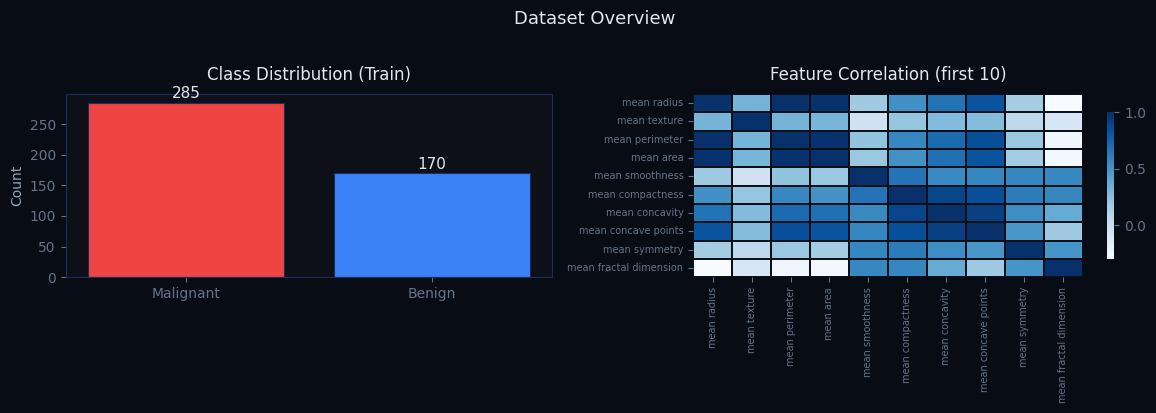

In [2]:
# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

print(f"Full dataset shape : {X.shape}")
print(f"Class distribution : {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"Feature names (first 6): {list(data.feature_names[:6])}")

# Train / test split (stratified)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standard scaling (fit on train only)
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test       = scaler.transform(X_test)

# Validation split from train (used inside BO objective)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full
)

print(f"\nTrain      : {X_train.shape[0]} samples")
print(f"Validation : {X_val.shape[0]}  samples")
print(f"Test       : {X_test.shape[0]}  samples")
print(f"Features   : {X_train.shape[1]}")

# Quick EDA
df = pd.DataFrame(X_train_full, columns=data.feature_names)
df['target'] = y_train_full

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
counts = pd.Series(y_train_full).value_counts()
colors = ['#ef4444', '#3b82f6']
axes[0].bar(['Malignant', 'Benign'], counts.values, color=colors, edgecolor='#1e2d5e', linewidth=0.8)
axes[0].set_title('Class Distribution (Train)', fontsize=12, color='#e2e8f0', pad=10)
axes[0].set_ylabel('Count', fontsize=10)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', va='bottom', color='#e2e8f0', fontsize=11)

# Feature correlation heatmap (first 10 features)
corr = df.iloc[:, :10].corr()
sns.heatmap(corr, ax=axes[1], cmap='Blues', linewidths=0.3,
            linecolor='#0d1117', annot=False, cbar_kws={'shrink': 0.8})
axes[1].set_title('Feature Correlation (first 10)', fontsize=12, color='#e2e8f0', pad=10)
axes[1].tick_params(labelsize=7)

plt.suptitle('Dataset Overview', color='#e2e8f0', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 3. Neural Network Architecture

<div style="background:#080c14;border:1px solid #1d3a6b;border-left:4px solid #38bdf8;border-radius:10px;padding:20px 24px;font-family:'Courier New',monospace;max-width:900px;margin:12px 0;">
  <div style="font-size:9px;letter-spacing:0.18em;text-transform:uppercase;color:#38bdf8;margin-bottom:10px;">// SECTION 03 · ARCHITECTURE</div>
  <div style="color:#cbd5e1;font-size:13px;line-height:1.7;margin-bottom:14px;">
    The <code>NeuralNetwork</code> class supports arbitrary depth and width, four activation functions, L2 regularization, and mini-batch SGD.
    Weight initialization uses <strong style="color:#7dd3fc;">He</strong> for ReLU/Leaky-ReLU and <strong style="color:#7dd3fc;">Xavier</strong> for Tanh/Sigmoid.
    Forward and backward passes cache intermediate values required for gradient computation.
  </div>
  <ul style="color:#94a3b8;font-size:12.5px;line-height:1.9;margin:0;padding-left:18px;">
    <li><strong style="color:#7dd3fc;">Supported activations:</strong> ReLU, Leaky-ReLU (alpha=0.01), Tanh, Sigmoid</li>
    <li><strong style="color:#7dd3fc;">Output layer:</strong> single sigmoid unit (binary classification)</li>
    <li><strong style="color:#7dd3fc;">Loss:</strong> binary cross-entropy with L2 weight decay</li>
    <li><strong style="color:#7dd3fc;">Update rule:</strong> mini-batch SGD with configurable batch size and learning rate</li>
  </ul>
</div>


In [3]:
class NeuralNetwork:
    '''Full-scratch feedforward neural network with backpropagation.'''

    def __init__(self, layer_sizes, activation='relu', lambda_reg=1e-4, seed=42):
        '''
        Parameters
        ----------
        layer_sizes : list[int]
            Neuron counts per layer including input and output.
            Example: [30, 64, 32, 1]
        activation  : str
            Hidden-layer activation. One of relu, leaky_relu, tanh, sigmoid.
        lambda_reg  : float
            L2 regularization coefficient.
        seed        : int
            NumPy random seed for reproducibility.
        '''
        np.random.seed(seed)
        self.layer_sizes = layer_sizes
        self.activation  = activation
        self.lambda_reg  = lambda_reg
        self.n_layers    = len(layer_sizes) - 1
        self.weights     = []
        self.biases      = []
        self.loss_history = []
        self._init_weights()

    # ── weight initialization ─────────────────────────────────────────────────
    def _init_weights(self):
        for i in range(self.n_layers):
            fan_in  = self.layer_sizes[i]
            fan_out = self.layer_sizes[i + 1]
            if self.activation in ('relu', 'leaky_relu'):
                scale = np.sqrt(2.0 / fan_in)           # He
            else:
                scale = np.sqrt(2.0 / (fan_in + fan_out))  # Xavier
            W = np.random.randn(fan_in, fan_out) * scale
            b = np.zeros((1, fan_out))
            self.weights.append(W)
            self.biases.append(b)

    # ── activation functions ──────────────────────────────────────────────────
    def _act(self, z, is_output=False):
        if is_output:
            return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
        fn = self.activation
        if fn == 'relu':       return np.maximum(0.0, z)
        if fn == 'leaky_relu': return np.where(z > 0, z, 0.01 * z)
        if fn == 'tanh':       return np.tanh(z)
        if fn == 'sigmoid':    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
        raise ValueError(f"Unknown activation: {fn}")

    def _act_deriv(self, a, z, is_output=False):
        if is_output:   return a * (1.0 - a)
        fn = self.activation
        if fn == 'relu':       return (z > 0.0).astype(float)
        if fn == 'leaky_relu': return np.where(z > 0, 1.0, 0.01)
        if fn == 'tanh':       return 1.0 - a ** 2
        if fn == 'sigmoid':    return a * (1.0 - a)

    # ── forward pass ──────────────────────────────────────────────────────────
    def forward(self, X):
        '''Compute output and cache intermediates for backprop.'''
        self._z_cache = []   # pre-activation values
        self._a_cache = [X]  # post-activation values (a[0] = input)
        a = X
        for i in range(self.n_layers):
            z = a @ self.weights[i] + self.biases[i]
            self._z_cache.append(z)
            is_out = (i == self.n_layers - 1)
            a = self._act(z, is_output=is_out)
            self._a_cache.append(a)
        return a  # shape (m, 1)

    # ── loss ──────────────────────────────────────────────────────────────────
    def compute_loss(self, y_pred, y_true):
        m   = y_true.shape[0]
        eps = 1e-12
        bce = -np.mean(
            y_true * np.log(y_pred + eps) +
            (1.0 - y_true) * np.log(1.0 - y_pred + eps)
        )
        l2  = (self.lambda_reg / (2.0 * m)) * sum(np.sum(w ** 2) for w in self.weights)
        return bce + l2

    # ── backward pass ─────────────────────────────────────────────────────────
    def backward(self, y_true, lr):
        '''
        Analytical backpropagation via chain rule.

        For cross-entropy loss with sigmoid output the combined gradient of
        loss w.r.t. the last pre-activation collapses to:
            delta_L = y_pred - y_true

        For hidden layers:
            delta_l = (delta_{l+1} @ W_{l+1}^T) * g_prime(z_l)

        Weight gradient with L2:
            dL/dW_l = (a_{l-1}^T @ delta_l) / m  +  (lambda/m) * W_l
        '''
        m       = y_true.shape[0]
        grads_w = [None] * self.n_layers
        grads_b = [None] * self.n_layers

        # Output layer: simplified delta for BCE + sigmoid
        delta = self._a_cache[-1] - y_true  # (m, 1)

        for i in reversed(range(self.n_layers)):
            grads_w[i] = (
                (self._a_cache[i].T @ delta) / m +
                (self.lambda_reg / m) * self.weights[i]
            )
            grads_b[i] = np.mean(delta, axis=0, keepdims=True)

            if i > 0:
                # Propagate error to previous layer
                delta = (delta @ self.weights[i].T) * \
                        self._act_deriv(self._a_cache[i], self._z_cache[i - 1])

        # SGD weight update
        for i in range(self.n_layers):
            self.weights[i] -= lr * grads_w[i]
            self.biases[i]  -= lr * grads_b[i]

        return grads_w, grads_b

    # ── training loop ─────────────────────────────────────────────────────────
    def fit(self, X, y, lr=0.01, n_epochs=300, batch_size=32, verbose=False):
        y = y.reshape(-1, 1).astype(float)
        m = X.shape[0]
        self.loss_history = []

        for epoch in range(n_epochs):
            idx       = np.random.permutation(m)
            X_shuf, y_shuf = X[idx], y[idx]
            epoch_loss = 0.0
            n_batches  = 0

            for start in range(0, m, batch_size):
                end    = min(start + batch_size, m)
                Xb, yb = X_shuf[start:end], y_shuf[start:end]
                yp     = self.forward(Xb)
                epoch_loss += self.compute_loss(yp, yb)
                self.backward(yb, lr)
                n_batches += 1

            avg_loss = epoch_loss / n_batches
            self.loss_history.append(avg_loss)
            if verbose and epoch % 50 == 0:
                val_acc = self.score(X_val, y_val) if 'X_val' in dir() else 0
                print(f"  Epoch {epoch:4d} | loss = {avg_loss:.5f}")

        return self

    # ── inference helpers ─────────────────────────────────────────────────────
    def predict_proba(self, X):
        return self.forward(X).flatten()

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))


print("NeuralNetwork class defined.")


NeuralNetwork class defined.


## 4. Backpropagation Engine Verification

<div style="background:#080c14;border:1px solid #14532d;border-left:4px solid #22c55e;border-radius:10px;padding:20px 24px;font-family:'Courier New',monospace;max-width:900px;margin:12px 0;">
  <div style="font-size:9px;letter-spacing:0.18em;text-transform:uppercase;color:#22c55e;margin-bottom:10px;">// SECTION 04 · GRADIENT VERIFICATION</div>
  <div style="color:#cbd5e1;font-size:13px;line-height:1.7;margin-bottom:8px;">
    Before using backprop for optimization we verify its correctness against <strong style="color:#86efac;">numerical gradients</strong> (finite differences).
    For each parameter theta, the numerical gradient approximates the partial derivative as:
  </div>

$$\frac{\partial L}{\partial \theta} \approx \frac{L(\theta + \varepsilon) - L(\theta - \varepsilon)}{2\varepsilon}$$

  <ul style="color:#94a3b8;font-size:12.5px;line-height:1.9;margin:0;padding-left:18px;">
    <li>Epsilon set to 1e-5 (balance between truncation and floating-point errors)</li>
    <li>Relative error below 1e-5 confirms analytical gradients are correct</li>
    <li>Checked on a tiny 2-layer network with 5 random samples</li>
  </ul>
</div>

In [4]:
def numerical_gradient_check(nn, X_check, y_check, eps=1e-5):
    '''
    Compare analytical backprop gradients against numerical finite differences.
    Returns max relative error across all checked parameters.
    '''
    y_check = y_check.reshape(-1, 1).astype(float)

    # Analytical gradients
    nn.forward(X_check)
    grads_analytical, _ = nn.backward(y_check, lr=0.0)  # lr=0 = no update

    max_rel_error = 0.0
    results = []

    for layer_idx in range(nn.n_layers):
        W = nn.weights[layer_idx]
        # Check a random subset of weights to keep runtime low
        check_indices = list(zip(
            np.random.randint(0, W.shape[0], min(6, W.shape[0])),
            np.random.randint(0, W.shape[1], min(6, W.shape[1]))
        ))
        for r, c in check_indices:
            orig = W[r, c]

            W[r, c] = orig + eps
            loss_plus = nn.compute_loss(nn.forward(X_check), y_check)

            W[r, c] = orig - eps
            loss_minus = nn.compute_loss(nn.forward(X_check), y_check)

            W[r, c] = orig  # restore

            num_grad  = (loss_plus - loss_minus) / (2.0 * eps)
            ana_grad  = grads_analytical[layer_idx][r, c]
            rel_error = abs(num_grad - ana_grad) / (abs(num_grad) + abs(ana_grad) + 1e-12)

            max_rel_error = max(max_rel_error, rel_error)
            results.append({
                'layer': layer_idx,
                'w_idx': f"[{r},{c}]",
                'numerical': f"{num_grad:.6f}",
                'analytical': f"{ana_grad:.6f}",
                'rel_error': f"{rel_error:.2e}",
                'status': 'PASS' if rel_error < 1e-4 else 'FAIL'
            })

    return max_rel_error, pd.DataFrame(results)


# Small network for gradient check
np.random.seed(0)
X_check = X_train[:5]
y_check = y_train[:5]

nn_check = NeuralNetwork([30, 8, 4, 1], activation='relu', lambda_reg=1e-3, seed=7)
nn_check.forward(X_check)  # populate cache

max_err, df_check = numerical_gradient_check(nn_check, X_check, y_check)

print("Gradient Check Results")
print("=" * 60)
print(df_check.to_string(index=False))
print("=" * 60)
status_str = "PASS" if max_err < 1e-4 else "FAIL"
print(f"\nMax relative error : {max_err:.2e}   [{status_str}]")
print("Threshold          : 1e-4")


Gradient Check Results
 layer  w_idx numerical analytical rel_error status
     0 [27,1]  0.030197   0.030197  1.07e-10   PASS
     0 [25,0]  0.096557   0.096557  3.99e-12   PASS
     0 [15,7]  0.021744   0.021744  4.73e-11   PASS
     0 [13,2] -0.004325  -0.004325  5.54e-10   PASS
     0  [1,4]  0.055061   0.055061  4.26e-11   PASS
     0  [0,2] -0.003022  -0.003022  1.07e-09   PASS
     1  [7,3]  0.107163   0.107163  1.00e-11   PASS
     1  [6,2] -0.000052  -0.000052  4.06e-08   PASS
     1  [3,3]  0.000098   0.000098  2.65e-08   PASS
     1  [1,1] -0.011620  -0.011620  5.16e-10   PASS
     2  [3,0]  0.208791   0.208791  2.04e-11   PASS

Max relative error : 4.06e-08   [PASS]
Threshold          : 1e-4


## 5. Bayesian Optimization over Hyperparameter Space

<div style="background:#080c14;border:1px solid #3b1e6b;border-left:4px solid #a78bfa;border-radius:10px;padding:20px 24px;font-family:'Courier New',monospace;max-width:900px;margin:12px 0;">
  <div style="font-size:9px;letter-spacing:0.18em;text-transform:uppercase;color:#a78bfa;margin-bottom:10px;">// SECTION 05 · BAYESIAN OPTIMIZATION</div>
  <div style="color:#cbd5e1;font-size:13px;line-height:1.7;margin-bottom:14px;">
    <code>gp_minimize</code> from <strong style="color:#c4b5fd;">scikit-optimize</strong> fits a Gaussian Process surrogate over the validation accuracy landscape.
    The acquisition function (EI) balances exploration and exploitation to find the hyperparameter configuration maximizing generalization with minimal evaluations.
  </div>
  <ul style="color:#94a3b8;font-size:12.5px;line-height:1.9;margin:0;padding-left:18px;">
    <li><strong style="color:#c4b5fd;">Objective:</strong> minimize negative validation accuracy (maximize accuracy)</li>
    <li><strong style="color:#c4b5fd;">n_calls:</strong> 30 evaluations total (5 random + 25 GP-guided)</li>
    <li><strong style="color:#c4b5fd;">Search space:</strong> learning rate, two hidden layer widths, activation, L2 lambda, epochs</li>
    <li><strong style="color:#c4b5fd;">Network shape:</strong> input(30) -> H1 -> H2 -> output(1)</li>
  </ul>
</div>


In [5]:
# ── Search space definition ──────────────────────────────────────────────────
search_space = [
    Real(   1e-4,  0.3,  prior='log-uniform', name='lr'        ),
    Integer(16,    128,                        name='h1'        ),
    Integer(8,     64,                         name='h2'        ),
    Categorical(['relu','tanh','leaky_relu'],   name='activation'),
    Real(   1e-5,  0.1,  prior='log-uniform', name='lambda_reg'),
    Integer(150,   400,                        name='n_epochs'  ),
]

# ── Objective function ────────────────────────────────────────────────────────
bo_call_count = [0]
bo_val_accs   = []

@use_named_args(search_space)
def objective(lr, h1, h2, activation, lambda_reg, n_epochs):
    bo_call_count[0] += 1
    nn = NeuralNetwork(
        layer_sizes=[30, int(h1), int(h2), 1],
        activation=activation,
        lambda_reg=float(lambda_reg),
        seed=42
    )
    nn.fit(X_train, y_train,
           lr=float(lr),
           n_epochs=int(n_epochs),
           batch_size=32,
           verbose=False)
    val_acc = nn.score(X_val, y_val)
    bo_val_accs.append(val_acc)
    if bo_call_count[0] % 5 == 0:
        print(f"  Call {bo_call_count[0]:2d} | val_acc = {val_acc:.4f} | "
              f"lr={lr:.5f}, H=[{int(h1)},{int(h2)}], act={activation}")
    return -val_acc   # minimize negative accuracy

# ── Run Bayesian Optimization ─────────────────────────────────────────────────
print("Starting Bayesian Optimization...")
print(f"Search space: lr, h1, h2, activation, lambda_reg, n_epochs")
print("-" * 65)

bo_result = gp_minimize(
    objective,
    search_space,
    n_calls         = 30,
    n_initial_points= 5,
    acq_func        = 'EI',
    random_state    = 42,
    verbose         = False
)

print("-" * 65)
print(f"\nBest validation accuracy : {-bo_result.fun:.4f}")

best = {dim.name: val for dim, val in zip(search_space, bo_result.x)}
print("\nOptimal hyperparameters:")
for k, v in best.items():
    print(f"  {k:12s} : {v}")


Starting Bayesian Optimization...
Search space: lr, h1, h2, activation, lambda_reg, n_epochs
-----------------------------------------------------------------
  Call  5 | val_acc = 0.9341 | lr=0.00021, H=[85,29], act=leaky_relu
  Call 10 | val_acc = 0.9670 | lr=0.30000, H=[44,8], act=leaky_relu
  Call 15 | val_acc = 0.9670 | lr=0.00076, H=[56,48], act=tanh
  Call 20 | val_acc = 0.9560 | lr=0.30000, H=[122,37], act=tanh
  Call 25 | val_acc = 0.9560 | lr=0.00491, H=[87,64], act=leaky_relu
  Call 30 | val_acc = 0.9670 | lr=0.03714, H=[77,8], act=relu
-----------------------------------------------------------------

Best validation accuracy : 0.9890

Optimal hyperparameters:
  lr           : 0.058840526473828696
  h1           : 37
  h2           : 52
  activation   : tanh
  lambda_reg   : 0.0006071989493441302
  n_epochs     : 175


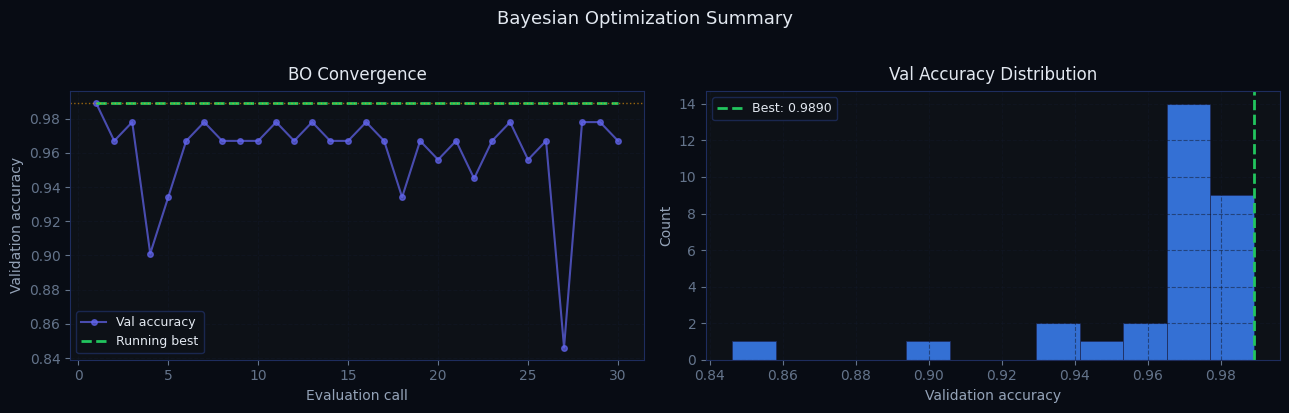

In [6]:
# ── BO convergence visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

calls = list(range(1, len(bo_val_accs) + 1))
running_best = np.maximum.accumulate(bo_val_accs)

axes[0].plot(calls, bo_val_accs, color='#6366f1', lw=1.5, alpha=0.7,
             marker='o', markersize=4, label='Val accuracy')
axes[0].plot(calls, running_best, color='#22c55e', lw=2.0, ls='--', label='Running best')
axes[0].axhline(y=running_best[-1], color='#f59e0b', lw=1, ls=':', alpha=0.6)
axes[0].set_title('BO Convergence', fontsize=12, color='#e2e8f0', pad=8)
axes[0].set_xlabel('Evaluation call')
axes[0].set_ylabel('Validation accuracy')
axes[0].legend(fontsize=9, facecolor='#0d1117', edgecolor='#1e2d5e', labelcolor='#e2e8f0')
axes[0].grid(True)

# Distribution of val accuracies across BO calls
axes[1].hist(bo_val_accs, bins=12, color='#3b82f6', edgecolor='#1e2d5e',
             alpha=0.85, linewidth=0.7)
axes[1].axvline(x=running_best[-1], color='#22c55e', lw=2, ls='--',
                label=f'Best: {running_best[-1]:.4f}')
axes[1].set_title('Val Accuracy Distribution', fontsize=12, color='#e2e8f0', pad=8)
axes[1].set_xlabel('Validation accuracy')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9, facecolor='#0d1117', edgecolor='#1e2d5e', labelcolor='#e2e8f0')
axes[1].grid(True)

plt.suptitle('Bayesian Optimization Summary', color='#e2e8f0', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 6. Diverse Sub-Model Training

<div style="background:#080c14;border:1px solid #14532d;border-left:4px solid #10b981;border-radius:10px;padding:20px 24px;font-family:'Courier New',monospace;max-width:900px;margin:12px 0;">
  <div style="font-size:9px;letter-spacing:0.18em;text-transform:uppercase;color:#10b981;margin-bottom:10px;">// SECTION 06 · SUB-MODEL TRAINING</div>
  <div style="color:#cbd5e1;font-size:13px;line-height:1.7;margin-bottom:14px;">
    Five diverse sub-models are trained using the BO-optimized hyperparameters as the anchor configuration. Each sub-model varies in architecture (depth, width) and seed to encourage diversity.
    This mirrors practical ensemble pipelines where BO identifies a strong base region and sub-models explore local variations.
  </div>
  <ul style="color:#94a3b8;font-size:12.5px;line-height:1.9;margin:0;padding-left:18px;">
    <li><strong style="color:#6ee7b7;">Sub-model 0:</strong> exact BO-optimal configuration (baseline)</li>
    <li><strong style="color:#6ee7b7;">Sub-model 1:</strong> wider H1 (1.5x), same depth</li>
    <li><strong style="color:#6ee7b7;">Sub-model 2:</strong> added third hidden layer, deeper architecture</li>
    <li><strong style="color:#6ee7b7;">Sub-model 3:</strong> Tanh activation with BO learning rate</li>
    <li><strong style="color:#6ee7b7;">Sub-model 4:</strong> leaky_relu with lighter regularization, different seed</li>
  </ul>
</div>


In [7]:
# Extract best HP values from BO
best_lr     = float(best['lr'])
best_h1     = int(best['h1'])
best_h2     = int(best['h2'])
best_act    = best['activation']
best_lam    = float(best['lambda_reg'])
best_epochs = int(best['n_epochs'])

# Sub-model configurations
sub_configs = [
    {
        'name'      : 'BO-Optimal',
        'layers'    : [30, best_h1, best_h2, 1],
        'activation': best_act,
        'lambda_reg': best_lam,
        'lr'        : best_lr,
        'epochs'    : best_epochs,
        'seed'      : 42,
    },
    {
        'name'      : 'Wide-H1',
        'layers'    : [30, int(best_h1 * 1.5), best_h2, 1],
        'activation': best_act,
        'lambda_reg': best_lam,
        'lr'        : best_lr,
        'epochs'    : best_epochs,
        'seed'      : 7,
    },
    {
        'name'      : 'Deep-3L',
        'layers'    : [30, best_h1, best_h2, max(8, best_h2 // 2), 1],
        'activation': best_act,
        'lambda_reg': best_lam * 1.5,
        'lr'        : best_lr * 0.8,
        'epochs'    : best_epochs + 50,
        'seed'      : 13,
    },
    {
        'name'      : 'Tanh-Act',
        'layers'    : [30, best_h1, best_h2, 1],
        'activation': 'tanh',
        'lambda_reg': best_lam,
        'lr'        : best_lr,
        'epochs'    : best_epochs,
        'seed'      : 21,
    },
    {
        'name'      : 'LeakyReLU-LightReg',
        'layers'    : [30, best_h1, best_h2, 1],
        'activation': 'leaky_relu',
        'lambda_reg': best_lam * 0.5,
        'lr'        : best_lr * 1.2,
        'epochs'    : best_epochs,
        'seed'      : 99,
    },
]

# Train all sub-models
trained_models = []
results        = []

print(f"{'Model':<24} {'Val Acc':>8} {'Test Acc':>9} {'F1':>8} {'AUC':>8}")
print("-" * 62)

for cfg in sub_configs:
    nn = NeuralNetwork(
        layer_sizes=cfg['layers'],
        activation =cfg['activation'],
        lambda_reg =cfg['lambda_reg'],
        seed       =cfg['seed'],
    )
    nn.fit(
        X_train_full, y_train_full,
        lr        = cfg['lr'],
        n_epochs  = cfg['epochs'],
        batch_size= 32,
        verbose   = False,
    )
    y_pred      = nn.predict(X_test)
    y_proba     = nn.predict_proba(X_test)
    val_acc     = nn.score(X_val, y_val)
    test_acc    = accuracy_score(y_test,  y_pred)
    f1          = f1_score(y_test, y_pred)
    auc         = roc_auc_score(y_test, y_proba)

    trained_models.append(nn)
    results.append({
        'Model'     : cfg['name'],
        'Arch'      : str(cfg['layers']),
        'Act'       : cfg['activation'],
        'LR'        : f"{cfg['lr']:.5f}",
        'Val Acc'   : val_acc,
        'Test Acc'  : test_acc,
        'F1'        : f1,
        'AUC'       : auc,
    })
    print(f"{cfg['name']:<24} {val_acc:>8.4f} {test_acc:>9.4f} {f1:>8.4f} {auc:>8.4f}")

print("-" * 62)
df_results = pd.DataFrame(results)
best_model_idx = df_results['Test Acc'].idxmax()
print(f"\nBest model on test set: {df_results.loc[best_model_idx, 'Model']}")
print(f"Test accuracy          : {df_results.loc[best_model_idx, 'Test Acc']:.4f}")


Model                     Val Acc  Test Acc       F1      AUC
--------------------------------------------------------------
BO-Optimal                 1.0000    0.9649   0.9718   0.9931
Wide-H1                    1.0000    0.9825   0.9861   0.9934
Deep-3L                    1.0000    0.9737   0.9790   0.9931
Tanh-Act                   1.0000    0.9649   0.9718   0.9934
LeakyReLU-LightReg         1.0000    0.9561   0.9645   0.9937
--------------------------------------------------------------

Best model on test set: Wide-H1
Test accuracy          : 0.9825


## 7. Evaluation and Analysis

<div style="background:#080c14;border:1px solid #3b1e6b;border-left:4px solid #c084fc;border-radius:10px;padding:20px 24px;font-family:'Courier New',monospace;max-width:900px;margin:12px 0;">
  <div style="font-size:9px;letter-spacing:0.18em;text-transform:uppercase;color:#c084fc;margin-bottom:10px;">// SECTION 07 · EVALUATION</div>
  <div style="color:#cbd5e1;font-size:13px;line-height:1.7;margin-bottom:14px;">
    Comprehensive evaluation of all sub-models: loss curves during training, per-model accuracy bar chart, confusion matrix for the best model, overlaid ROC curves for all sub-models, and a final results summary table.
  </div>
  <ul style="color:#94a3b8;font-size:12.5px;line-height:1.9;margin:0;padding-left:18px;">
    <li>Loss curves confirm convergence and absence of divergence</li>
    <li>Confusion matrix reveals precision/recall trade-off for the top model</li>
    <li>ROC curves and AUC quantify discrimination across classification thresholds</li>
  </ul>
</div>


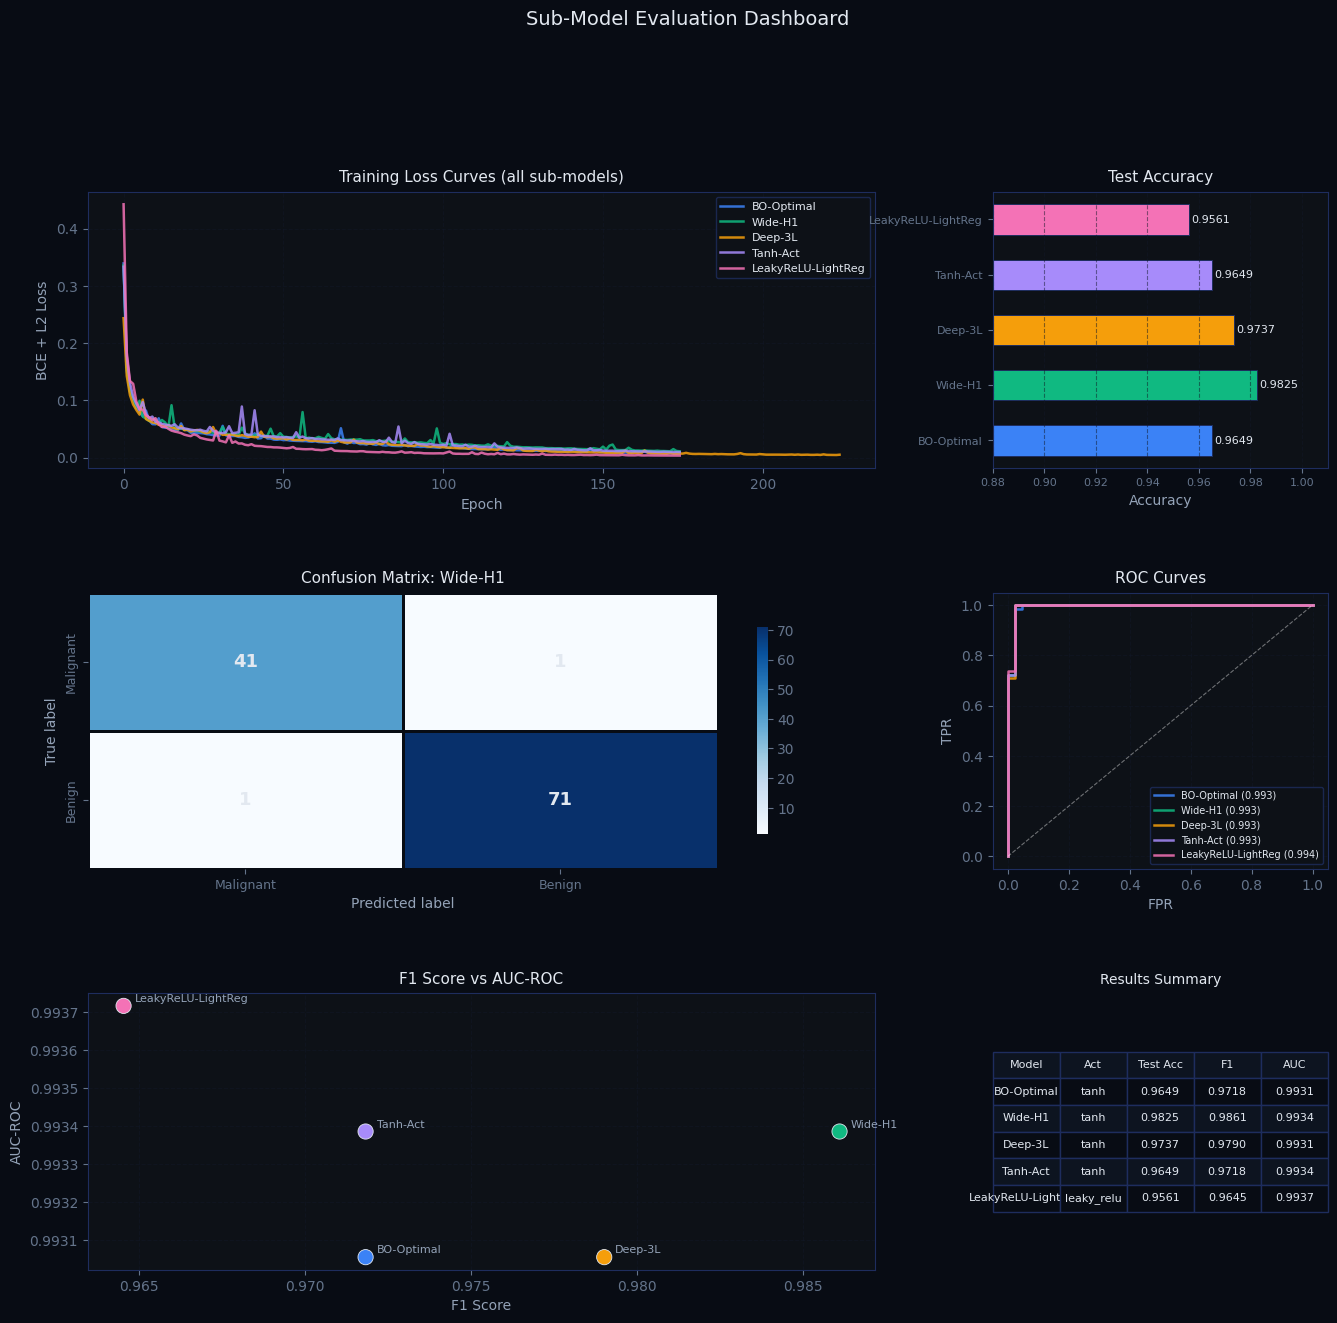


Classification Report: Wide-H1
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [8]:
palette = ['#3b82f6', '#10b981', '#f59e0b', '#a78bfa', '#f472b6']

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Training loss curves ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
for i, (nn, row) in enumerate(zip(trained_models, results)):
    ax1.plot(nn.loss_history, color=palette[i], lw=1.8, alpha=0.85,
             label=row['Model'])
ax1.set_title('Training Loss Curves (all sub-models)', color='#e2e8f0', fontsize=11, pad=7)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE + L2 Loss')
ax1.legend(fontsize=8, facecolor='#0d1117', edgecolor='#1e2d5e', labelcolor='#e2e8f0',
           loc='upper right')
ax1.grid(True)

# ── Panel 2: Test accuracy bar chart ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
names = [r['Model'] for r in results]
accs  = [r['Test Acc'] for r in results]
bars  = ax2.barh(names, accs, color=palette, edgecolor='#1e2d5e', linewidth=0.7, height=0.55)
ax2.set_xlim(0.88, 1.01)
ax2.set_title('Test Accuracy', color='#e2e8f0', fontsize=11, pad=7)
ax2.set_xlabel('Accuracy')
for bar, acc in zip(bars, accs):
    ax2.text(acc + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{acc:.4f}', va='center', fontsize=8, color='#e2e8f0')
ax2.grid(True, axis='x')
ax2.tick_params(labelsize=8)

# ── Panel 3: Confusion matrix for best model ─────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
best_nn   = trained_models[best_model_idx]
y_pred_bm = best_nn.predict(X_test)
cm        = confusion_matrix(y_test, y_pred_bm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            linewidths=1, linecolor='#080c14',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            cbar_kws={'shrink': 0.75},
            annot_kws={'size': 13, 'weight': 'bold', 'color': '#e2e8f0'})
ax3.set_title(f'Confusion Matrix: {results[best_model_idx]["Model"]}',
              color='#e2e8f0', fontsize=11, pad=7)
ax3.set_xlabel('Predicted label'); ax3.set_ylabel('True label')
ax3.tick_params(labelsize=9)

# ── Panel 4: ROC curves ───────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
for i, (nn, row) in enumerate(zip(trained_models, results)):
    fpr, tpr, _ = roc_curve(y_test, nn.predict_proba(X_test))
    ax4.plot(fpr, tpr, color=palette[i], lw=1.8, alpha=0.85,
             label=f"{row['Model']} ({row['AUC']:.3f})")
ax4.plot([0, 1], [0, 1], 'w--', lw=0.8, alpha=0.4)
ax4.set_title('ROC Curves', color='#e2e8f0', fontsize=11, pad=7)
ax4.set_xlabel('FPR'); ax4.set_ylabel('TPR')
ax4.legend(fontsize=7, facecolor='#0d1117', edgecolor='#1e2d5e', labelcolor='#e2e8f0')
ax4.grid(True)

# ── Panel 5: F1 vs AUC scatter ────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
f1s  = [r['F1']  for r in results]
aucs = [r['AUC'] for r in results]
sc   = ax5.scatter(f1s, aucs, c=palette[:len(results)], s=120,
                   edgecolors='#e2e8f0', linewidths=0.6, zorder=3)
for i, row in enumerate(results):
    ax5.annotate(row['Model'], (f1s[i], aucs[i]),
                 textcoords='offset points', xytext=(8, 3),
                 fontsize=8, color='#94a3b8')
ax5.set_title('F1 Score vs AUC-ROC', color='#e2e8f0', fontsize=11, pad=7)
ax5.set_xlabel('F1 Score'); ax5.set_ylabel('AUC-ROC')
ax5.grid(True)

# ── Panel 6: Results table ────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
col_labels = ['Model', 'Act', 'Test Acc', 'F1', 'AUC']
table_data = [
    [r['Model'], r['Act'], f"{r['Test Acc']:.4f}", f"{r['F1']:.4f}", f"{r['AUC']:.4f}"]
    for r in results
]
tbl = ax6.table(
    cellText   = table_data,
    colLabels  = col_labels,
    cellLoc    = 'center',
    loc        = 'center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.6)
for (row_i, col_i), cell in tbl.get_celld().items():
    cell.set_facecolor('#0d1420' if row_i % 2 == 0 else '#080c14')
    cell.set_edgecolor('#1e2d5e')
    cell.set_text_props(color='#e2e8f0')
ax6.set_title('Results Summary', color='#e2e8f0', fontsize=10, pad=7)

fig.patch.set_facecolor('#080c14')
plt.suptitle('Sub-Model Evaluation Dashboard', color='#e2e8f0', fontsize=14, y=1.01)
plt.show()

# Classification report for best model
print(f"\nClassification Report: {results[best_model_idx]['Model']}")
print("=" * 55)
print(classification_report(y_test, y_pred_bm,
                             target_names=['Malignant', 'Benign']))
